In [1]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Step 2: Create a mock dataset (You can replace with HR dataset)
data = {
    'Age': [25, 30, 45, 35, 40, 29, 50, 28, 32, 41],
    'Salary': [30000, 40000, 60000, 50000, 65000, 35000, 70000, 33000, 42000, 68000],
    'Years_at_Company': [1, 3, 10, 6, 8, 2, 12, 1, 4, 11],
    'JobSatisfaction': [3, 4, 2, 4, 5, 3, 5, 2, 3, 4],
    'Attrition': ['Leave', 'Stay', 'Stay', 'Stay', 'Stay', 'Leave', 'Stay', 'Leave', 'Stay', 'Stay']
}

In [3]:
df = pd.DataFrame(data)

In [4]:
# Step 3: Features and Target
X = df[['Age', 'Salary', 'Years_at_Company', 'JobSatisfaction']]
y = df['Attrition']

In [5]:
# Step 4: Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [6]:
# Step 5: Train Decision Tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [7]:
# Step 6: Predictions
y_pred = dt.predict(X_test)

In [8]:
print("Predictions:", y_pred.tolist())
print("Actual:", y_test.tolist())
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Predictions: ['Leave', 'Stay', 'Stay']
Actual: ['Leave', 'Stay', 'Stay']

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 2]]

Classification Report:
               precision    recall  f1-score   support

       Leave       1.00      1.00      1.00         1
        Stay       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



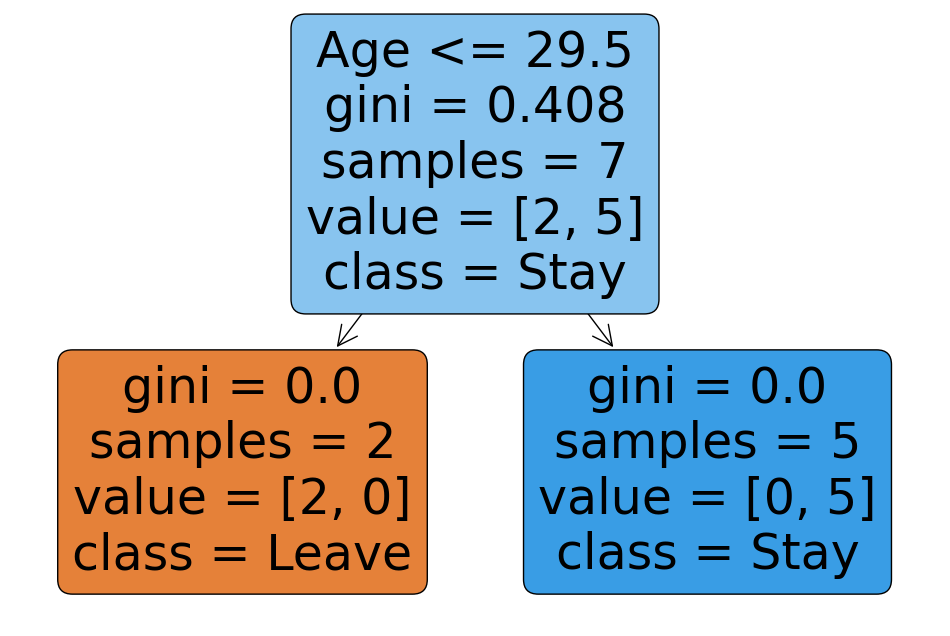

In [9]:
# Step 7: Visualize the Tree
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=X.columns, class_names=dt.classes_, 
          filled=True, rounded=True)
plt.show()

In [10]:
# Step 8: Feature Importance
importances = dt.feature_importances_
features = X.columns
idx = np.argsort(importances)[::-1]

In [11]:
print("\nFeature Importances:")
for i in idx:
    print(f"{features[i]}: {importances[i]:.4f}")


Feature Importances:
Age: 1.0000
JobSatisfaction: 0.0000
Years_at_Company: 0.0000
Salary: 0.0000
